## Image saliency prediction

Prediction of one image with the three configurations of each model. The final prediction is the mean of the predictions produced by the 3 CV folds.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights


In [16]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Running on GPU")
else:
    device = torch.device('cpu')
    print("Running on CPU")

Running on GPU


In [17]:
# insert: path of the images and maps. If dataset has no maps, set HAS_MAPS to false
image_path = Path("dataset/images/test/COCO_test2014_000000000627.jpg")
HAS_MAPS = False
map_path = Path("dataset/maps/train/") if HAS_MAPS else None

RUNS = [("SS Scratch", "SS_scratch"), ("SS Finetuned", "SS_pretrained_finetuned"), ("SS Frozen", "SS_pretrained_frozen"),
        ("ML Scratch", "ML_scratch"), ("ML Finetuned", "ML_pretrained_finetuned"), ("ML Frozen", "ML_pretrained_frozen")]

## SSResNet18

In [18]:
class resnet18_encoder(nn.Module):
    def __init__(self, pretrained=False, frozen=False):
        super().__init__()
        weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        resnet = resnet18(weights=weights)

        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.layer4[0].conv1.stride = (1, 1)
        self.layer4[0].downsample[0].stride = (1, 1)
        self.frozen = frozen

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x


class decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up_layer1 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.up_layer2 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.up_layer3 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.up_layer4 = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.classifier = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        x = self.up_layer1(x)
        x = self.up_layer2(x)
        x = self.up_layer3(x)
        x = self.up_layer4(x)
        return self.classifier(x)


class SSResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = resnet18_encoder()
        self.decoder = decoder()

    def forward(self, x):
        return self.decoder(self.encoder(x))

## MLResNet18

In [19]:
class MLresnet18_encoder(nn.Module):
    def __init__(self, pretrained=False, frozen=False):
        super().__init__()
        weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        resnet = resnet18(weights=weights)

        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.layer4[0].conv1.stride = (1, 1)
        self.layer4[0].downsample[0].stride = (1, 1)
        self.frozen = frozen

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        feature1 = self.layer1(x)
        feature2 = self.layer2(feature1)
        x = self.layer3(feature2)
        feature3 = self.layer4(x)
        return feature1, feature2, feature3


class MLdecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.projection1 = nn.Conv2d(64, 256, kernel_size=1)
        self.projection2 = nn.Conv2d(128, 512, kernel_size=1)
        self.projection3 = nn.Conv2d(512, 512, kernel_size=1)

        self.decoder1_up_layer1 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(inplace=True))
        self.decoder1_up_layer2 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(inplace=True))
        self.classifier1 = nn.Conv2d(64, 1, kernel_size=1)

        self.decoder2_up_layer1 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(inplace=True))
        self.decoder2_up_layer2 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(inplace=True))
        self.decoder2_up_layer3 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(inplace=True))
        self.classifier2 = nn.Conv2d(64, 1, kernel_size=1)

        self.decoder3_up_layer1 = nn.Sequential(nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.ReLU(inplace=True))
        self.decoder3_up_layer2 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(inplace=True))
        self.decoder3_up_layer3 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(inplace=True))
        self.decoder3_up_layer4 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(inplace=True))
        self.classifier3 = nn.Conv2d(64, 1, kernel_size=1)

        self.fusion = nn.Conv2d(3, 1, kernel_size=1)

    def forward(self, features):
        feature1, feature2, feature3 = features

        feature1 = self.projection1(feature1)
        feature2 = self.projection2(feature2)
        feature3 = self.projection3(feature3)

        x1 = self.decoder1_up_layer1(feature1)
        x1 = self.decoder1_up_layer2(x1)
        logit1 = self.classifier1(x1)

        x2 = self.decoder2_up_layer1(feature2)
        x2 = self.decoder2_up_layer2(x2)
        x2 = self.decoder2_up_layer3(x2)
        logit2 = self.classifier2(x2)

        x3 = self.decoder3_up_layer1(feature3)
        x3 = self.decoder3_up_layer2(x3)
        x3 = self.decoder3_up_layer3(x3)
        x3 = self.decoder3_up_layer4(x3)
        logit3 = self.classifier3(x3)

        fused = self.fusion(torch.cat((logit1, logit2, logit3), dim=1))
        return {"level1": logit1, "level2": logit2, "level3": logit3, "fused": fused}


class MLResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MLresnet18_encoder()
        self.decoder = MLdecoder()

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [20]:
def build_model(run_name):
    if run_name.startswith("SS_"):
        return SSResNet18()
    if run_name.startswith("ML_"):
        return MLResNet18()


def load_model(run_name, checkpoint_path):
    model = build_model(run_name)
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)

    if "model_state_dict" in checkpoint:
        checkpoint = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]

    model.load_state_dict(checkpoint, strict=True)
    return model.to(device).eval()


@torch.inference_mode()
def ensemble_prediction(image, run_name):
    fold_predictions = []

    for fold in [1, 2, 3]:
        checkpoint_path = Path("training_runs") / run_name / f"fold_{fold}" / "best_model.pth"

        model = load_model(run_name, checkpoint_path)

        output = model(image.unsqueeze(0).to(device))
        logits = output["fused"] if isinstance(output, dict) else output
        prediction = torch.sigmoid(logits).squeeze()

        fold_predictions.append(prediction)

        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return torch.stack(fold_predictions).mean(dim=0).cpu().numpy()


mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(image):
    return (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def overlay(image, saliency, alpha=0.65):
    saliency = saliency - saliency.min()

    if saliency.max() > 0:
        saliency = saliency / saliency.max()

    heat = plt.get_cmap("jet")(saliency)[:, :, :3]
    alpha_map = alpha * saliency[:, :, None]

    return np.clip((1 - alpha_map) * image + alpha_map * heat, 0, 1)

In [21]:
img_transf = transforms.Compose([transforms.Resize((480, 640)), transforms.ToTensor(), transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
map_transf = transforms.Compose([transforms.Resize((480, 640)), transforms.ToTensor()])

image_pil = Image.open(image_path).convert("RGB")
image = img_transf(image_pil)

target = None
if HAS_MAPS:
    target = map_transf(Image.open(map_path).convert("L"))[0].numpy()

predictions = {}

for label, run_name in RUNS:
    predictions[label] = ensemble_prediction(image, run_name)

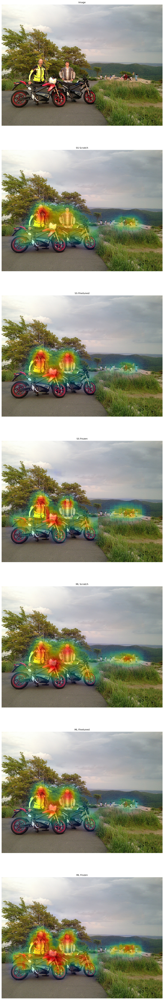

In [26]:
image_den= denormalize(image)
panels = [("Image", image_den)]

if HAS_MAPS:
    panels.append(("Ground Truth", overlay(image_den, target)))

panels += [(label, overlay(image_den, predictions[label])) for label, _ in RUNS]

fig, axes = plt.subplots(len(panels), figsize=(160, 80))
axes = axes.flatten()

for ax, (label, panel) in zip(axes, panels):
    ax.imshow(panel)
    ax.set_title(label, fontsize=10)
    ax.axis("off")
plt.show()